#### Imports and Setups

In [1]:
import yaml
import pandas as pd
from io import StringIO
from pathlib import Path
from dotenv import load_dotenv
from rich.markdown import Markdown
from langgraph_utils import console
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from typing import TypedDict, Literal, Dict, Any
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser
from langchain_community.tools import DuckDuckGoSearchRun

params_configs = yaml.safe_load(Path("configs/params.yaml").read_text())
prompts_configs = yaml.safe_load(Path("configs/prompts.yaml").read_text())
load_dotenv()

/var/folders/ws/q25zxpw551g_fb_gbm7t6v700000gn/T/ipykernel_26775/3561529849.py:15: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


True

#### Output Formats

In [2]:
class ToolDecision(BaseModel):
    tool_required: Literal["Yes", "No"]


class ToolSelection(BaseModel):
    tool_selected: Literal["math_eval", "file_search", "web_search"]
    tool_params: Dict

#### Model & Parser

In [3]:
model = ChatGoogleGenerativeAI(**params_configs["default_llm"])
parser = StrOutputParser()

#### State

In [4]:
class ToolState(TypedDict):
    query: str

    tool_required: Literal["Yes", "No"]
    tool_selected: Literal["no_tool", "math_eval", "file_search", "web_search"]
    tool_params: Dict

    response: str

#### Tools

In [5]:
@tool
def math_eval(expression: str):
    """
    Evaluate a mathematical expression and return the result.
    Args:
        expression: Mathematical expression to evaluate.
    Returns:
        A dictionary containing the evaluation result or an error message.
    """
    try:
        res = eval(expression)
        return {"response": res}

    except Exception as e:
        return {"response": str(e)}


@tool
def file_search(filename: str):
    """
    Search for a file in the current directory tree and return its contents.
    Args:
        filename: Name of the file to locate.
    Returns:
        A dictionary containing the file contents if found, otherwise None.
    """
    try:
        current_dir = Path.cwd()
        for file_path in current_dir.rglob(filename):
            if file_path.is_file():
                content = file_path.read_text(encoding="utf-8")
                return {"response": content}

        return {"response": "File not found"}

    except Exception as e:
        return {"response": "File not found"}


@tool
def web_search(search_query: str):
    """
    Search the web for information related to a query.
    Args:
        query: Search query.
    Returns:
        A dictionary containing the search results.
    """
    try:
        search_engine = DuckDuckGoSearchRun()
        res = search_engine.invoke(search_query)
        return {"response": res}

    except Exception as e:
        return {"response": str(e)}


def llm_call(state: ToolState):
    llm = ChatGoogleGenerativeAI(**params_configs["no_tool_llm"])
    chain = llm | parser
    return {"response": chain.invoke(state["query"])}


#### Node & Helper Functions

In [6]:
def require_tool(state: ToolState) -> dict:
    structured_model = model.with_structured_output(ToolDecision)
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", prompts_configs["require_tool"]["system_prompt"]),
            ("user", "{query}"),
        ]
    )

    chain = prompt | structured_model
    result = chain.invoke({"query": state["query"]})

    return {"tool_required": result.tool_required}


def select_tool(state: ToolState) -> dict:
    structured_model = model.with_structured_output(ToolSelection)
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", prompts_configs["select_tool"]["system_prompt"]),
            ("user", "{query}"),
        ]
    )

    chain = prompt | structured_model
    result = chain.invoke({"query": state["query"]})

    return {
        "tool_selected": result.tool_selected,
        "tool_params": result.tool_params,
    }

In [7]:
def route_tool_required(state: ToolState) -> Literal["Yes", "No"]:
    return state["tool_required"]


def route_tool_selection(state: ToolState) -> Literal["math_eval", "file_search", "web_search"]:
    return state["tool_selected"]

In [8]:
def math_eval_node(state: ToolState) -> dict:
    result = math_eval.invoke(state["tool_params"]["expression"])
    return {"response": result["response"]}


def file_search_node(state: ToolState) -> dict:
    result = file_search.invoke(state["tool_params"]["filename"])
    return {"response": result["response"]}


def web_search_node(state: ToolState) -> dict:
    result = web_search.invoke(state["tool_params"]["search_query"])
    return {"response": result["response"]}


#### Init Graph

In [9]:
graph = StateGraph(ToolState)

#### Add Nodes

In [10]:
graph.add_node("require_tool", require_tool)
graph.add_node("select_tool", select_tool)

graph.add_node("llm_call", llm_call)
graph.add_node("math_eval", math_eval_node)
graph.add_node("file_search", file_search_node)
graph.add_node("web_search", web_search_node)

#### Add Edges

In [11]:
graph.add_edge(START, "require_tool")

graph.add_conditional_edges("require_tool", route_tool_required, {"No": "llm_call", "Yes": "select_tool"})
graph.add_conditional_edges("select_tool", route_tool_selection)

graph.add_edge("llm_call", END)
graph.add_edge("math_eval", END)
graph.add_edge("file_search", END)
graph.add_edge("web_search", END)

#### Compilation

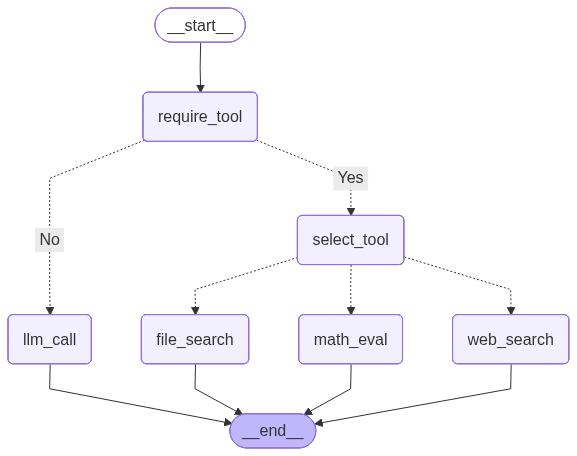

In [12]:
workflow = graph.compile()
workflow

### Execution

Web Search


In [13]:
final_state_search = workflow.invoke({"query": "what is current oil price per gallon?"})
console.print_json(data={k: v for k, v in final_state_search.items() if k != "response"})
console.print(final_state_search["response"])

{
  "query": "what is current oil price per gallon?",
  "tool_required": "Yes",
  "tool_selected": "web_search",
  "tool_params": {
    "search_query": "current oil price per gallon"
  }
}
4 hours ago · Oil and Petroleum Products. Spot Prices (Crude Oil in Dollars per Barrel, Products in Dollars per Gallon) 
Period: Daily 95.00 91.90 93.68. Brent - Europe 97.46 ... 1 Jun 2026 · As of 8:30 a.m. Eastern Time on June 1, 2026, oil
sold for $96.42 per barrel (using Brent as the benchmark, which we'll get into momentarily). 15 Jun 2026 · Interactive 
chart showing the daily closing price for West Texas. The prices shown are in U.S. dollars. Data ranges from 3.324 to 
120.43. 12 Mar 2026 · reaching $101.4 a barrel. Expect oil at $200 per barrel," they said. One barrel of oil is equal to
159 litres - around 42 US gallons (or roughly 35 UK gallons). 18 Mar 2026 · Drivers now pay an average of $3.84 per 
gallon, up from $2.92 a month ago and the highest level since September 2023, according to d

File Search

In [14]:
final_state_file = workflow.invoke({"query": "read loan_application_status.csv"})
console.print_json(data={k: v for k, v in final_state_file.items() if k != "response"})
pd.read_csv(StringIO(final_state_file["response"]))

{
  "query": "read loan_application_status.csv",
  "tool_required": "Yes",
  "tool_selected": "file_search",
  "tool_params": {
    "filename": "loan_application_status.csv"
  }
}


,Unnamed: 0,name,age,employment_years,monthly_income,credit_score,loan_amount,eligibility_status,credit_score_category,risk_category,approval_status
0,0,Rahul Sharma,30,5,100000,800,20000,Eligible,S,Low,Approve
1,1,Priya Patel,28,3,100000,680,50000,Eligible,A,Medium,Reject
2,2,Amit Verma,35,7,100000,500,10000,Eligible,C,Low,Reject
3,3,Rohan Singh,19,1,50000,850,10000,Not Eligible,NaN,NaN,Reject
4,4,Neha Gupta,32,4,50000,780,100000,Eligible,S,High,Reject
5,5,Karan Mehta,26,2,70000,720,25000,Eligible,A,Medium,Reject
6,6,Sneha Joshi,29,6,120000,790,30000,Eligible,S,Low,Approve
7,7,Vikas Rao,40,10,150000,640,60000,Eligible,B,Medium,Reject
8,8,Anjali Kulkarni,24,2,60000,560,15000,Eligible,B,Low,Reject
9,9,Manoj Desai,45,15,200000,810,50000,Eligible,S,Low,Approve


Maths Expression

In [15]:
final_state_math = workflow.invoke({"query": "what is 2 ** 9 / (3 ** 4)"})
console.print_json(data=final_state_math)


{
  "query": "what is 2 ** 9 / (3 ** 4)",
  "tool_required": "Yes",
  "tool_selected": "math_eval",
  "tool_params": {
    "expression": "2 ** 9 / (3 ** 4)"
  },
  "response": 6.320987654320987
}


LLM call

In [16]:
final_state_llm = workflow.invoke({"query": "explain MAP@K in about 200 words"})

console.print_json(data={k: v for k, v in final_state_llm.items() if k != "response"})
console.print(Markdown(final_state_llm["response"]))

{
  "query": "explain MAP@K in about 200 words",
  "tool_required": "No"
}
MAP@K (Mean Average Precision at K) is a premier metric for evaluating ranking systems, such as search engines and      
recommendation algorithms, focusing on the top $K$ results. It is highly valued because it is order-sensitive; it       
heavily penalizes systems that place relevant items lower in the list.                                                  

To calculate MAP@K, we break it down into three steps:                                                                  

 1 Precision at $i$ ($P@i$): The fraction of relevant items in the top $i$ results.                                     
 2 Average Precision at K ($AP@K$): For a single query, we calculate $P@i$ at every position $i$ (up to $K$) where a    
   relevant item is found. We sum these precision scores and divide by the total number of actual relevant items.       
   Because we only sum at the positions of relevant items, placing them at t